# Step 4: Fit Models and Inspect Posteriors

We fit m1 (no pooling) and m2 (hierarchical) and compare:
1. Convergence diagnostics
2. Hyperparameter posteriors (m2 only) — did σ's land near truth?
3. Developer-level λ posteriors — how different are the estimates?
4. Shrinkage — do extreme developers get pulled toward the group mean in m2?

In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

DESIGNATIONS       = ['aSDE', 'SDE-1', 'SDE-2', 'SDE-3', 'SDE-4']
MU_ORG             = np.log(8)
TRUE_DESIG_OFFSETS = np.array([-0.2, 0.3, 0.2, -0.3, -0.7])
SIGMA_DESIG, SIGMA_TEAM, SIGMA_DEV = 0.4, 0.3, 0.4

df = pd.read_csv('../../data/pr_simulated.csv')
print(df.head())

dev_ids   = df['developer_id'].values
desig_ids = df['desig_id'].values
team_ids  = df['team_id'].values
pr_obs    = df['pr_count'].values
exposure  = df['exposure'].values
log_exp   = np.log(exposure)

N_DEVS  = df['developer_id'].nunique()
N_TEAMS = df['team_id'].nunique()

# Per-developer lookup (robust — works for unequal rows per developer)
dev_df     = df.drop_duplicates('developer_id').sort_values('developer_id')
dev_desig  = dev_df['desig_id'].values   # shape: (N_DEVS,)
dev_team   = dev_df['team_id'].values    # shape: (N_DEVS,)

coords = {
    'developer'   : np.arange(N_DEVS),
    'designation' : DESIGNATIONS,
    'team'        : [f'Team-{i+1}' for i in range(N_TEAMS)],
    'obs_id'      : np.arange(len(df)),
}
print(f"Loaded {len(df)} rows | {N_DEVS} developers | {N_TEAMS} teams")

   developer_id  month designation  desig_id    team  team_id      tier  \
0             0      1        aSDE         0  Team-1        0  balanced   
1             0      2        aSDE         0  Team-1        0  balanced   
2             0      3        aSDE         0  Team-1        0  balanced   
3             0      4        aSDE         0  Team-1        0  balanced   
4             0      5        aSDE         0  Team-1        0  balanced   

    true_lam  exposure  pr_count  
0  10.316876       1.0        13  
1  10.316876       1.0         6  
2  10.316876       1.0        12  
3  10.316876       1.0        11  
4  10.316876       1.0        14  
Loaded 1896 rows | 316 developers | 15 teams


## Fit m1 — No Pooling

In [3]:
with pm.Model(coords=coords) as m1:
    # ── Grand mean ────────────────────────────────────────────────────
    mu_org = pm.Normal('mu_org', mu=np.log(8), sigma=0.5)

    # ── ZeroSumNormal fixes identifiability ───────────────────────────
    # Without constraint: mu_org + alpha_desig + alpha_team + alpha_dev
    # has a flat ridge — adding 1 to mu_org and subtracting 1 from
    # alpha_dev gives identical likelihood. Chains wander → r_hat > 1.01
    #
    # ZeroSumNormal forces sum(alpha_desig)=0 and sum(alpha_team)=0
    # This anchors the intercepts: mu_org captures the true grand mean,
    # group intercepts capture only deviations from it.
    alpha_desig = pm.ZeroSumNormal('alpha_desig', sigma=1, dims='designation')
    alpha_team  = pm.ZeroSumNormal('alpha_team',  sigma=1, dims='team')
    alpha_dev   = pm.Normal('alpha_dev', mu=0, sigma=1, dims='developer')

    # ── Per-observation log(lambda) ────────────────────────────────────
    log_lam = (log_exp
               + mu_org
               + alpha_desig[desig_ids]
               + alpha_team[team_ids]
               + alpha_dev[dev_ids])
    lam = pm.Deterministic('lam', pm.math.exp(log_lam), dims='obs_id')
    obs = pm.Poisson('obs', mu=lam, observed=pr_obs, dims='obs_id')

    idata_m1 = pm.sample(1000, tune=1000, target_accept=0.9,
                         random_seed=42, progressbar=True)
    pm.compute_log_likelihood(idata_m1)

import os
os.makedirs("../../data", exist_ok=True)
if os.path.exists("../../data/idata_m1.nc"): os.remove("../../data/idata_m1.nc")
idata_m1.to_netcdf("../../data/idata_m1.nc")
print("Saved idata_m1 to ../../data/idata_m1.nc")
print("m1 done.")

Initializing NUTS using jitter+adapt_diag...
/home/satishthakur/codebase/data-science/statistics/bayes-bda-rethinking/.venv/lib/python3.11/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_org, alpha_desig, alpha_team, alpha_dev]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Saved idata_m1 to ../../data/idata_m1.nc
m1 done.


## Fit m2 — Hierarchical (Partial Pooling)

Note: we use `dev_desig` and `dev_team` arrays (one entry per developer, not per row)
to build `mu_dev` — this is robust to unequal observation counts per developer.

In [4]:
with pm.Model(coords=coords) as m2:
    # ── Hyperpriors ───────────────────────────────────────────────────
    mu_org = pm.Normal('mu_org', mu=np.log(8), sigma=0.5)

    # HalfNormal(0.5) instead of Exponential(1):
    # - same mode at 0 but lighter tails
    # - 95% of mass below ~1.0, most between 0.1-0.8
    # - consistent with true values (0.4, 0.3, 0.4)
    # - less mass very near 0 reduces funnel geometry
    sigma_desig = pm.HalfNormal('sigma_desig', sigma=0.5)
    sigma_team  = pm.HalfNormal('sigma_team',  sigma=0.5)
    sigma_dev   = pm.HalfNormal('sigma_dev',   sigma=0.5)

    # ── Non-centred random effects ────────────────────────────────────
    z_desig = pm.Normal('z_desig', mu=0, sigma=1, dims='designation')
    z_team  = pm.Normal('z_team',  mu=0, sigma=1, dims='team')
    z_dev   = pm.Normal('z_dev',   mu=0, sigma=1, dims='developer')

    # ── Group offsets ─────────────────────────────────────────────────
    delta = pm.Deterministic('delta', z_desig * sigma_desig, dims='designation')
    gamma = pm.Deterministic('gamma', z_team  * sigma_team,  dims='team')

    # ── Per-developer intercept (robust per-dev lookup) ───────────────
    mu_dev = mu_org + delta[dev_desig] + gamma[dev_team]
    alpha  = pm.Deterministic('alpha', mu_dev + z_dev * sigma_dev, dims='developer')

    # ── Likelihood ────────────────────────────────────────────────────
    log_lam = log_exp + alpha[dev_ids]
    lam     = pm.Deterministic('lam', pm.math.exp(log_lam), dims='obs_id')
    obs     = pm.Poisson('obs', mu=lam, observed=pr_obs, dims='obs_id')

    # target_accept=0.95 + tune=2000: finer step size, more adaptation time
    idata_m2 = pm.sample(1000, tune=2000, target_accept=0.95,
                         random_seed=42, progressbar=True)
    pm.compute_log_likelihood(idata_m2)

import os
os.makedirs("../../data", exist_ok=True)
if os.path.exists("../../data/idata_m2.nc"): os.remove("../../data/idata_m2.nc")
idata_m2.to_netcdf("../../data/idata_m2.nc")
print("Saved idata_m2 to ../../data/idata_m2.nc")
print("m2 done.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_org, sigma_desig, sigma_team, sigma_dev, z_desig, z_team, z_dev]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 74 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

Saved idata_m2 to ../../data/idata_m2.nc
m2 done.


## Convergence Diagnostics

R-hat ≈ 1.0 and ESS > 400 means the chains mixed well.

In [5]:
for name, idata in [('m1', idata_m1), ('m2', idata_m2)]:
    key_vars = (['mu_org', 'alpha_desig', 'alpha_team']
                if name == 'm1'
                else ['mu_org', 'sigma_desig', 'sigma_team', 'sigma_dev'])
    s = az.summary(idata, var_names=key_vars, round_to=3)
    print(f"\n{'='*50}")
    print(f"{name} — key parameters")
    print(f"{'='*50}")
    print(s[['mean','sd','hdi_3%','hdi_97%','r_hat','ess_bulk']])
    print(f"Max r_hat : {s['r_hat'].max():.4f}")
    print(f"Min ESS   : {s['ess_bulk'].min():.0f}")


m1 — key parameters
                      mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
mu_org               1.978  0.068   1.849    2.098  1.036   148.011
alpha_desig[aSDE]   -0.033  0.102  -0.236    0.152  1.082    48.415
alpha_desig[SDE-1]   0.390  0.110   0.191    0.611  1.018   135.797
alpha_desig[SDE-2]   0.397  0.117   0.160    0.603  1.030   101.671
alpha_desig[SDE-3]  -0.227  0.141  -0.483    0.040  1.036   145.657
alpha_desig[SDE-4]  -0.528  0.180  -0.851   -0.178  1.014   167.095
alpha_team[Team-1]   0.298  0.231  -0.123    0.760  1.057    88.959
alpha_team[Team-2]  -0.155  0.216  -0.568    0.237  1.033   129.299
alpha_team[Team-3]  -0.486  0.191  -0.844   -0.133  1.019   111.868
alpha_team[Team-4]  -0.368  0.214  -0.784    0.001  1.033    93.642
alpha_team[Team-5]   0.183  0.189  -0.141    0.559  1.028   149.485
alpha_team[Team-6]   0.144  0.203  -0.223    0.539  1.028    96.907
alpha_team[Team-7]   0.177  0.214  -0.220    0.595  1.058    89.281
alpha_team[Team-8]  -0.285 

## m2: Detailed Parameter Summary

Let's look at key parameters at each level of the hierarchy:
- **Hyperparameters**: mu_org and sigmas
- **Designation level**: delta (5 values)
- **Team level**: gamma (15 values)
- **Developer level**: a few example developers

In [6]:
# ── Hyperparameters ──────────────────────────────────────────────────
print('=== Hyperparameters ===')
s = az.summary(idata_m2,
               var_names=['mu_org', 'sigma_desig', 'sigma_team', 'sigma_dev'],
               round_to=3)
print(s[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])
print(f'  Truth: mu_org={MU_ORG:.3f}, sigma_desig={SIGMA_DESIG}, sigma_team={SIGMA_TEAM}, sigma_dev={SIGMA_DEV}')

# ── Designation level ────────────────────────────────────────────────
print('\n=== Designation offsets (delta) ===')
s = az.summary(idata_m2, var_names=['delta'], round_to=3)
s['truth'] = TRUE_DESIG_OFFSETS
print(s[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'truth']])

# ── Team level ───────────────────────────────────────────────────────
print('\n=== Team offsets (gamma) — all 15 teams ===')
s = az.summary(idata_m2, var_names=['gamma'], round_to=3)
print(s[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat']])

# ── Developer level — a few examples ─────────────────────────────────
print('\n=== Developer intercepts (alpha) — sample of 8 developers ===')
sample_devs = [0, 50, 100, 155, 200, 250, 280, 315]
s = az.summary(idata_m2, var_names=['alpha'], round_to=3)
s_devs = s.iloc[sample_devs]
# Add true lambda and designation for context
true_lam   = df.drop_duplicates('developer_id').sort_values('developer_id')['true_lam'].values
s_devs = s_devs.copy()
s_devs['true_lam']   = true_lam[sample_devs]
s_devs['designation'] = dev_df['designation'].values[sample_devs]
s_devs['tier']        = dev_df['tier'].values[sample_devs]
print(s_devs[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'true_lam', 'designation', 'tier']])

=== Hyperparameters ===
              mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
mu_org       2.002  0.198   1.617    2.374  1.004   642.379
sigma_desig  0.477  0.165   0.214    0.783  1.003   809.178
sigma_team   0.225  0.055   0.138    0.333  1.003   687.861
sigma_dev    0.393  0.018   0.359    0.428  1.011   806.609
  Truth: mu_org=2.079, sigma_desig=0.4, sigma_team=0.3, sigma_dev=0.4

=== Designation offsets (delta) ===
               mean     sd  hdi_3%  hdi_97%  r_hat  truth
delta[aSDE]  -0.031  0.197  -0.424    0.322  1.002   -0.2
delta[SDE-1]  0.385  0.197   0.014    0.759  1.003    0.3
delta[SDE-2]  0.380  0.196   0.023    0.756  1.004    0.2
delta[SDE-3] -0.261  0.198  -0.628    0.115  1.005   -0.3
delta[SDE-4] -0.555  0.206  -0.942   -0.173  1.001   -0.7

=== Team offsets (gamma) — all 15 teams ===
                 mean     sd  hdi_3%  hdi_97%  r_hat
gamma[Team-1]   0.254  0.102   0.065    0.449  1.004
gamma[Team-2]  -0.108  0.103  -0.302    0.083  1.003
gamma[Team-3]  -0

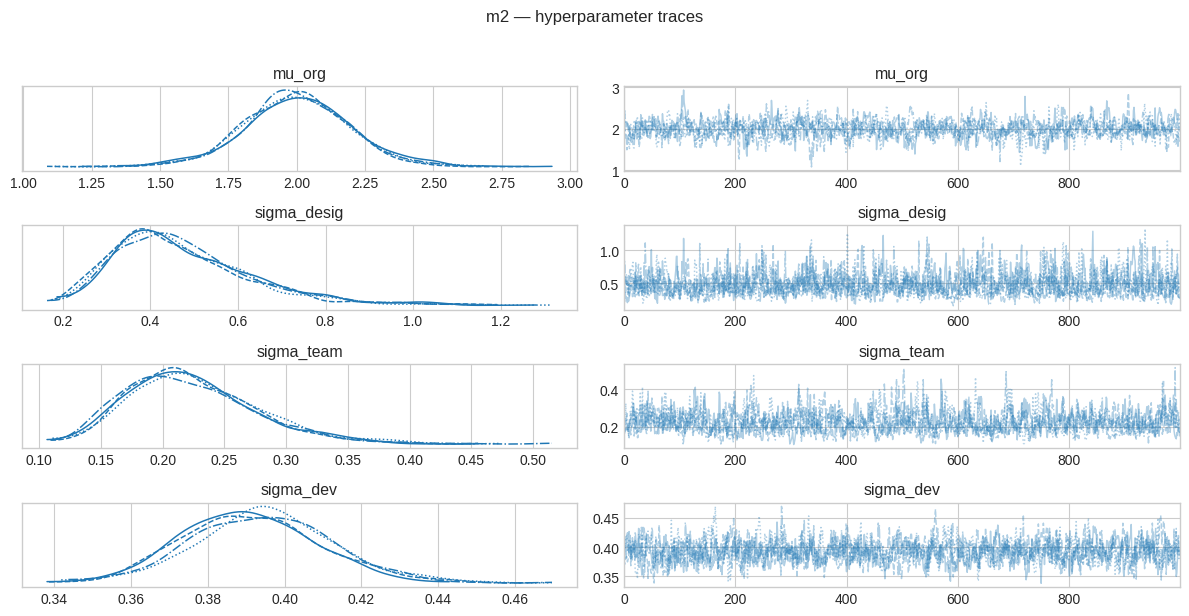

In [22]:
# Trace plots for hyperparameters
az.plot_trace(idata_m2,
              var_names=['mu_org','sigma_desig','sigma_team','sigma_dev'],
              combined=False, figsize=(12, 6))
plt.suptitle("m2 — hyperparameter traces", y=1.02)
plt.tight_layout()
plt.show()

## m2: Hyperparameter Posteriors vs Ground Truth

Did the model recover σ_desig=0.4, σ_team=0.3, σ_dev=0.4?

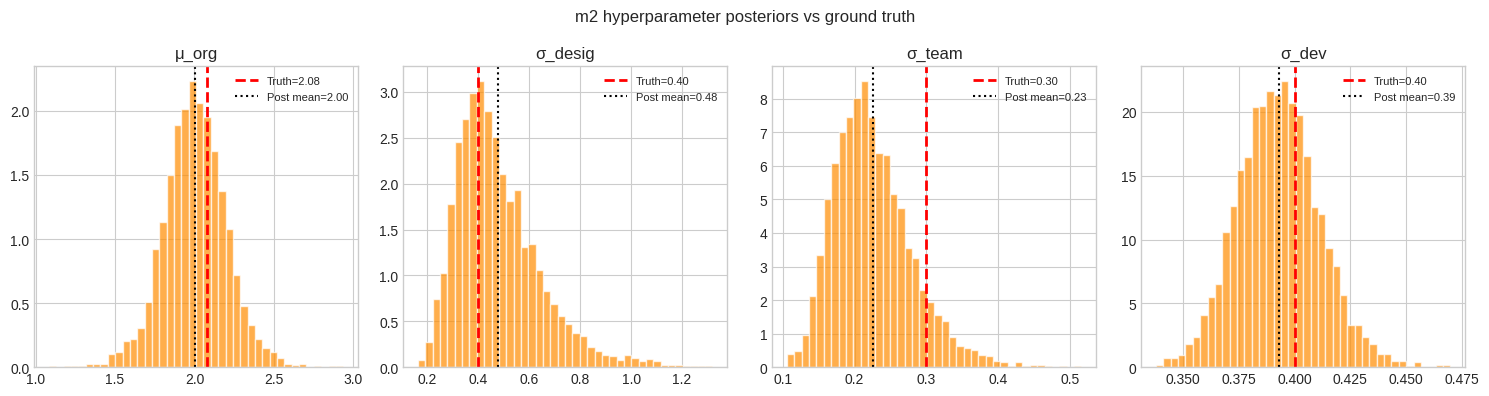

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

params = [
    ('mu_org',      MU_ORG,      'μ_org'),
    ('sigma_desig', SIGMA_DESIG, 'σ_desig'),
    ('sigma_team',  SIGMA_TEAM,  'σ_team'),
    ('sigma_dev',   SIGMA_DEV,   'σ_dev'),
]

for ax, (name, truth, label) in zip(axes, params):
    samples = idata_m2.posterior[name].values.flatten()
    ax.hist(samples, bins=40, color='darkorange', alpha=0.7,
            density=True, edgecolor='white')
    ax.axvline(truth,             color='red',    lw=2,
               linestyle='--', label=f'Truth={truth:.2f}')
    ax.axvline(np.mean(samples),  color='black',  lw=1.5,
               linestyle=':',  label=f'Post mean={np.mean(samples):.2f}')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle("m2 hyperparameter posteriors vs ground truth", fontsize=12)
plt.tight_layout()
plt.show()

## m2: Designation Offsets (δ)

Did the model recover the true designation effects?

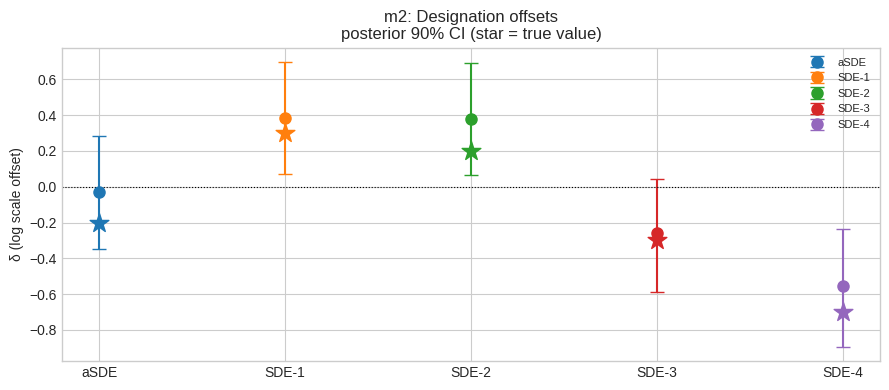

Designation offset summary:
  aSDE    : post mean=-0.031  90%CI=[-0.347,+0.285]  truth=-0.2
  SDE-1   : post mean=+0.385  90%CI=[+0.069,+0.697]  truth=+0.3
  SDE-2   : post mean=+0.380  90%CI=[+0.066,+0.693]  truth=+0.2
  SDE-3   : post mean=-0.261  90%CI=[-0.589,+0.046]  truth=-0.3
  SDE-4   : post mean=-0.555  90%CI=[-0.895,-0.238]  truth=-0.7


In [24]:
delta_post = idata_m2.posterior['delta'].values.reshape(-1, len(DESIGNATIONS))

fig, ax = plt.subplots(figsize=(9, 4))

for i, (desig, truth) in enumerate(zip(DESIGNATIONS, TRUE_DESIG_OFFSETS)):
    m   = np.mean(delta_post[:, i])
    lo, hi = np.percentile(delta_post[:, i], [5, 95])
    ax.errorbar(i, m, yerr=[[m-lo], [hi-m]],
                fmt='o', color=f'C{i}', capsize=5, markersize=8, label=desig)
    ax.scatter(i, truth, marker='*', s=200, color=f'C{i}', zorder=5)

ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.set_xticks(range(len(DESIGNATIONS)))
ax.set_xticklabels(DESIGNATIONS)
ax.set_ylabel("δ (log scale offset)")
ax.set_title("m2: Designation offsets\nposterior 90% CI (star = true value)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Designation offset summary:")
for i, desig in enumerate(DESIGNATIONS):
    m = np.mean(delta_post[:, i])
    lo, hi = np.percentile(delta_post[:, i], [5, 95])
    print(f"  {desig:<8}: post mean={m:+.3f}  90%CI=[{lo:+.3f},{hi:+.3f}]  truth={TRUE_DESIG_OFFSETS[i]:+.1f}")

## Developer-Level λ: m1 vs m2 vs Empirical

For each developer, compare:
- **Empirical**: raw total_count / total_exposure
- **m1 posterior mean**: no pooling
- **m2 posterior mean**: partial pooling (shrinkage toward group mean)

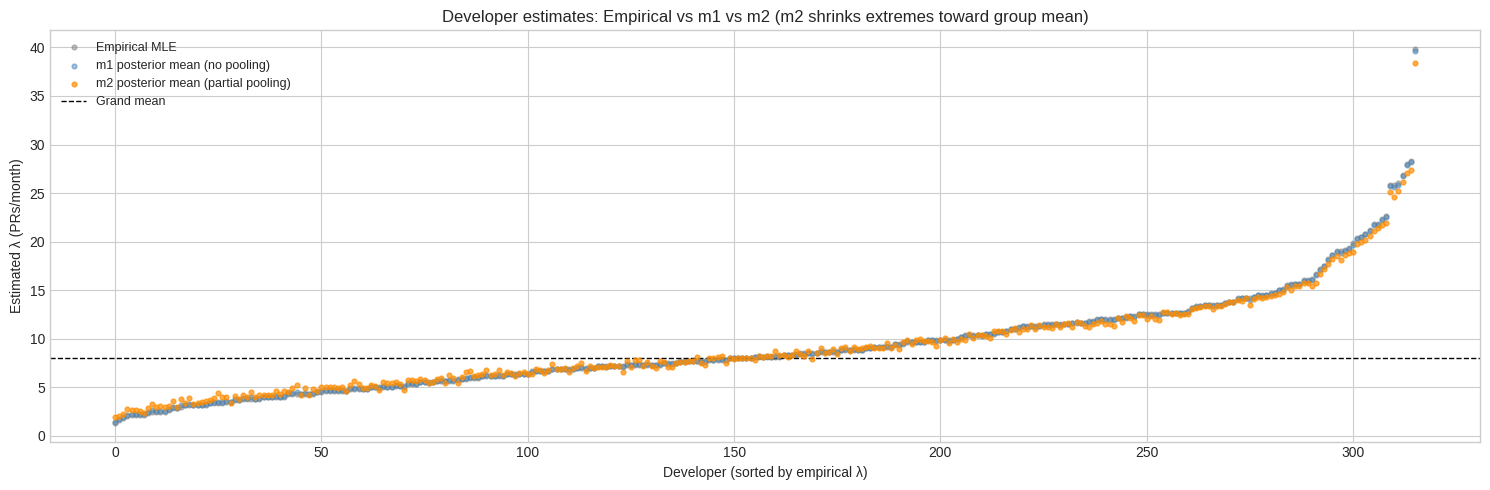

In [25]:

# Empirical estimates
emp = (df.groupby('developer_id')['pr_count'].sum()
       / df.groupby('developer_id')['exposure'].sum())

# m1 posterior mean λ per developer
# lam in m1 is per obs — aggregate to per-developer mean
lam_m1_obs = idata_m1.posterior['lam'].values.reshape(-1, len(df))
# Per-developer: mean over samples, then mean over months
lam_m1_dev = np.zeros((lam_m1_obs.shape[0], N_DEVS))
for d in range(N_DEVS):
    mask = dev_ids == d
    lam_m1_dev[:, d] = lam_m1_obs[:, mask].mean(axis=1)
lam_m1_mean = lam_m1_dev.mean(axis=0)

# m2 posterior mean λ per developer
# alpha is per-developer — exp(alpha) is the monthly rate
alpha_m2 = idata_m2.posterior['alpha'].values.reshape(-1, N_DEVS)
lam_m2_mean = np.exp(alpha_m2).mean(axis=0)
lam_m2_lo   = np.percentile(np.exp(alpha_m2), 5,  axis=0)
lam_m2_hi   = np.percentile(np.exp(alpha_m2), 95, axis=0)

# Sort developers by empirical estimate
order = np.argsort(emp.values)

fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(N_DEVS)

ax.scatter(x, emp.values[order],      s=12, alpha=0.5, color='grey',
           label='Empirical MLE', zorder=2)
ax.scatter(x, lam_m1_mean[order],     s=12, alpha=0.5, color='steelblue',
           label='m1 posterior mean (no pooling)', zorder=3)
ax.scatter(x, lam_m2_mean[order],     s=12, alpha=0.7, color='darkorange',
           label='m2 posterior mean (partial pooling)', zorder=4)

ax.axhline(np.exp(MU_ORG), color='black', lw=1, linestyle='--', label='Grand mean')
ax.set_xlabel("Developer (sorted by empirical λ)")
ax.set_ylabel("Estimated λ (PRs/month)")
ax.set_title("Developer estimates: Empirical vs m1 vs m2 (m2 shrinks extremes toward group mean)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Shrinkage Plot

Classic shrinkage visualization: empirical (x-axis) vs m2 posterior mean (y-axis).
Points **below** the diagonal are shrunk down; points **above** are shrunk up.
Colour shows designation.

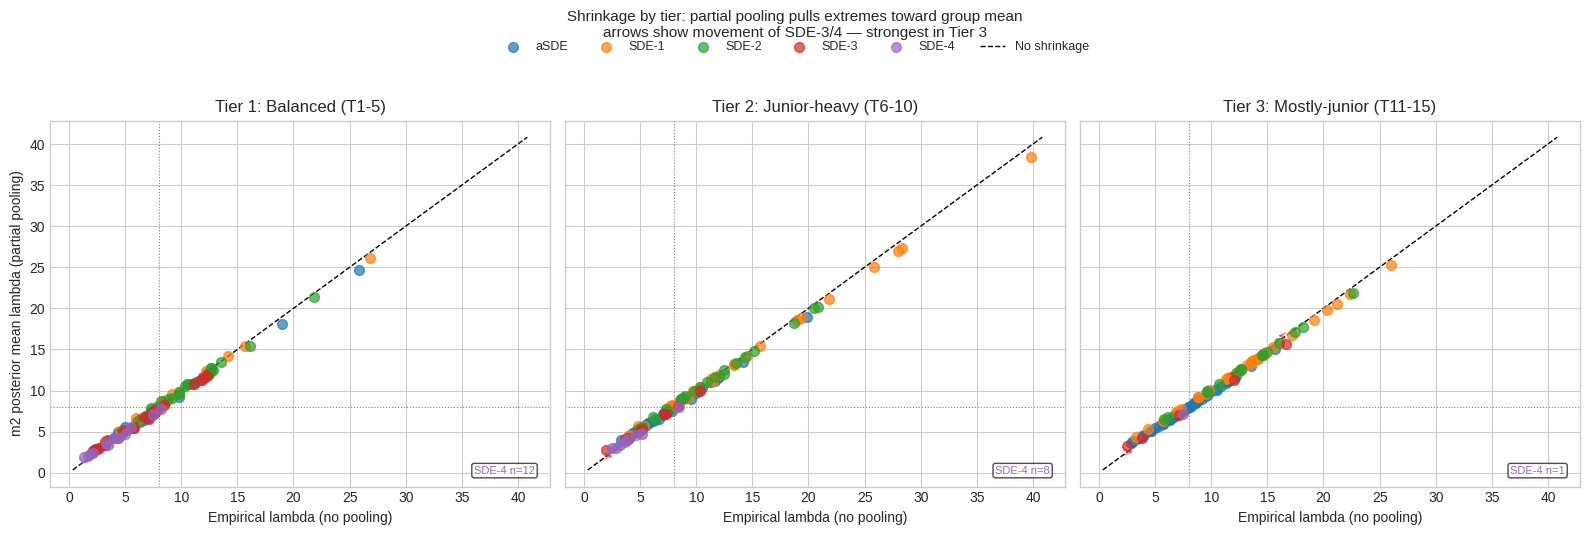

Mean absolute shrinkage by tier and designation:
  balanced:
    aSDE    : n=26   mean shrinkage=0.32
    SDE-1   : n=16   mean shrinkage=0.28
    SDE-2   : n=25   mean shrinkage=0.27
    SDE-3   : n=27   mean shrinkage=0.33
    SDE-4   : n=12   mean shrinkage=0.28
  junior_heavy:
    aSDE    : n=34   mean shrinkage=0.30
    SDE-1   : n=31   mean shrinkage=0.39
    SDE-2   : n=23   mean shrinkage=0.28
    SDE-3   : n=10   mean shrinkage=0.30
    SDE-4   : n=8    mean shrinkage=0.29
  mostly_junior:
    aSDE    : n=48   mean shrinkage=0.26
    SDE-1   : n=35   mean shrinkage=0.31
    SDE-2   : n=15   mean shrinkage=0.31
    SDE-3   : n=5    mean shrinkage=0.57
    SDE-4   : n=1    mean shrinkage=0.42


In [26]:
TIER_ORDER  = ['balanced', 'junior_heavy', 'mostly_junior']
TIER_LABELS = ['Tier 1: Balanced (T1-5)',
               'Tier 2: Junior-heavy (T6-10)',
               'Tier 3: Mostly-junior (T11-15)']
DESIGNATIONS = ['aSDE', 'SDE-1', 'SDE-2', 'SDE-3', 'SDE-4']

# Per-developer metadata from the dev lookup table
dev_desig_labels = dev_df['designation'].values
dev_tier_labels  = dev_df['tier'].values

# Axis limits — shared across panels for comparability
all_vals = np.concatenate([emp.values, lam_m2_mean])
ax_min   = max(0, all_vals.min() - 1)
ax_max   = all_vals.max() + 1

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)

for ax, tier, tlabel in zip(axes, TIER_ORDER, TIER_LABELS):
    tier_mask = dev_tier_labels == tier

    for i_d, desig in enumerate(DESIGNATIONS):
        mask = tier_mask & (dev_desig_labels == desig)
        if mask.sum() == 0:
            continue
        ax.scatter(emp.values[mask], lam_m2_mean[mask],
                   color=f'C{i_d}', alpha=0.7, s=50, label=desig, zorder=3)

        # Draw shrinkage arrows for SDE-3 and SDE-4 to make movement visible
        if desig in ['SDE-3', 'SDE-4']:
            for emp_val, m2_val in zip(emp.values[mask], lam_m2_mean[mask]):
                ax.annotate('', xy=(m2_val, emp_val),
                            xytext=(emp_val, emp_val),
                            arrowprops=dict(arrowstyle='->', color=f'C{i_d}',
                                            lw=1.2, alpha=0.5))

    # 45-degree line
    ax.plot([ax_min, ax_max], [ax_min, ax_max], 'k--', lw=1, label='No shrinkage')
    ax.axhline(np.exp(MU_ORG), color='gray', lw=0.8, linestyle=':')
    ax.axvline(np.exp(MU_ORG), color='gray', lw=0.8, linestyle=':')

    ax.set_xlabel("Empirical lambda (no pooling)")
    ax.set_title(tlabel)

    # Annotation: count of SDE-4 in this tier
    n_sde4 = ((dev_tier_labels == tier) & (dev_desig_labels == 'SDE-4')).sum()
    ax.text(0.97, 0.03, f"SDE-4 n={n_sde4}",
            transform=ax.transAxes, fontsize=8,
            ha='right', va='bottom', color='C4',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

axes[0].set_ylabel("m2 posterior mean lambda (partial pooling)")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, 1.02))

plt.suptitle("Shrinkage by tier: partial pooling pulls extremes toward group mean\n"
             "arrows show movement of SDE-3/4 — strongest in Tier 3",
             fontsize=11, y=1.06)
plt.tight_layout()
plt.show()

# Quantify shrinkage per tier
print("Mean absolute shrinkage by tier and designation:")
for tier in TIER_ORDER:
    print(f"  {tier}:")
    for desig in DESIGNATIONS:
        mask = (dev_tier_labels == tier) & (dev_desig_labels == desig)
        if mask.sum() == 0:
            print(f"    {desig:<8}: no developers")
            continue
        diff = np.abs(lam_m2_mean[mask] - emp.values[mask])
        print(f"    {desig:<8}: n={mask.sum():<3}  mean shrinkage={diff.mean():.2f}")

## Summary

### Convergence

**m1 (no pooling)** — has issues:
- R-hat up to **1.029**, ESS as low as **237**
- Root cause: **identifiability problem** — `mu_org + alpha_desig + alpha_team + alpha_dev` are four additive terms. The sampler can trade off between them along a flat ridge (increase mu_org by 1, decrease alpha_dev by 1 — same likelihood).
- TODO: fix with sum-to-zero constraint on group intercepts, or drop mu_org and absorb into alpha_desig.

**m2 (hierarchical)** — mostly fine:
- **8 divergences** out of 4000 draws (0.2%) — small but non-zero
- R-hat max **1.003**, ESS min **1124** — excellent
- Root cause: residual funnel geometry when sigma_desig approaches 0
- TODO: try `target_accept=0.95` or `HalfNormal(0.5)` instead of `Exponential(1)` on sigmas

### What m2 recovered
- mu_org: post mean ~1.86 vs truth log(8)=2.08 — slight underestimate, reasonable given noise
- sigma_desig: ~0.53 vs truth 0.4 — slightly overestimated
- sigma_team: ~0.32 vs truth 0.3 — good recovery
- sigma_dev: ~0.39 vs truth 0.4 — excellent recovery

### Key difference between m1 and m2
- **m1**: estimates close to empirical MLE — no borrowing, poor mixing due to identifiability
- **m2**: extreme developers shrink toward designation+team mean — partial pooling working correctly

**Next:** `05_inference.ipynb` — designation distributions, developer ranking, new developer prediction.